# Práctica 1 - Procesamiento del corpus

El notebook sigue el orden de la rúbrica. Los archivos `.txt` del corpus son la fuente original y no se sobrescriben durante el preprocesamiento.

In [84]:
from pathlib import Path
import sys
import pandas as pd

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
CORPUS_DIR = ROOT / "corpus"
METADATA_PATH = CORPUS_DIR / "metadata.csv"
metadata = pd.read_csv(METADATA_PATH)
metadata.head()

,doc_id,label,source_type,source_name,url,title,date,n_words,topic,file,original_id
0,ds_falso_0001,0,dataset,fuente2_kaggle,NaN,El órgano que fiscaliza al Gobierno andaluz de...,NaN,58,politica,Falso/ds_falso_0001.txt,ID
1,ds_falso_0002,0,dataset,fuente2_kaggle,NaN,PP pide a Cristina Narbona igualar los permiso...,NaN,50,politica,Falso/ds_falso_0002.txt,ID
2,ds_falso_0003,0,dataset,fuente2_kaggle,NaN,Cristina Narbona rebaja las hipótesis electora...,NaN,49,politica,Falso/ds_falso_0003.txt,ID
3,ds_falso_0004,0,dataset,fuente2_kaggle,NaN,"Carrero Blanco, elegida candidata del Iniciati...",NaN,47,politica,Falso/ds_falso_0004.txt,ID
4,ds_falso_0005,0,dataset,fuente2_kaggle,NaN,Diego Cañamero pide aprobar ya los presupuesto...,NaN,40,politica,Falso/ds_falso_0005.txt,ID


## 1. Creación y caracterización del corpus

El corpus definitivo contiene 5.300 documentos: 5.000 del dataset de Kaggle y 300 obtenidos mediante web scraping. La generación se realiza con `src/get_corpus_dataset.py` y `src/scrape_corpus.py`; cada script conserva los archivos de la otra fuente.

In [85]:
metadata["label_name"] = metadata["label"].map({0: "Falso", 1: "Verdad"})
metadata.groupby(["source_name", "label_name"]).size().unstack(fill_value=0)

label_name,Falso,Verdad
source_name,,
bbc_mundo,0,150
fuente2_kaggle,2500,2500
newtral,150,0


In [86]:
metrics = (
    metadata.groupby("source_name")["n_words"]
    .agg(
        count="count",
        mean="mean",
        std="std",
        min="min",
        max="max",
        q25=lambda values: values.quantile(0.25),
        q50=lambda values: values.quantile(0.50),
        q75=lambda values: values.quantile(0.75),
        sum="sum",
    )
    .rename(columns={"count": "Count", "mean": "Mean", "std": "Std", "min": "Min", "max": "Max", "q25": "Q25", "q50": "Q50", "q75": "Q75", "sum": "Sum"})
    .round(2)
)
metrics

,Count,Mean,Std,Min,Max,Q25,Q50,Q75,Sum
source_name,,,,,,,,,
bbc_mundo,150,1176.32,822.18,61,3940,591.5,1058.5,1651.25,176448
fuente2_kaggle,5000,54.20,15.78,20,177,44.0,53.0,62.00,271012
newtral,150,753.59,894.53,220,10762,471.5,608.5,806.50,113039


In [87]:
assert len(metadata) == 5300
assert metadata["label"].value_counts().to_dict() == {0: 2650, 1: 2650}
assert metadata["source_name"].value_counts().to_dict() == {"fuente2_kaggle": 5000, "newtral": 150, "bbc_mundo": 150}
assert all((CORPUS_DIR / row.file).exists() for row in metadata.itertuples())
print("Corpus válido: 5.300 documentos.")

Corpus válido: 5.300 documentos.


## 2. Preprocesamiento

Esta fase se ejecuta después de crear el corpus. Incluye minúsculas, eliminación de tildes, números, URLs, saltos de línea, HTML, puntuación y emoticones. El resultado se guarda en una columna nueva para conservar el texto crudo.

In [88]:
from src.preprocess import clean_text, preprocess_dataframe

# Carga explícita del texto original desde los TXT.
metadata["text"] = metadata["file"].map(
    lambda relative_path: (CORPUS_DIR / relative_path).read_text(encoding="utf-8")
)
processed = preprocess_dataframe(metadata, text_column="text", output_column="clean_text")
processed[["doc_id", "label_name", "text", "clean_text"]].head(3)

,doc_id,label_name,text,clean_text
0,ds_falso_0001,Falso,El órgano que fiscaliza al Gobierno andaluz de...,el organo que fiscaliza al gobierno andaluz de...
1,ds_falso_0002,Falso,PP pide a Cristina Narbona igualar los permiso...,pp pide a cristina narbona igualar los permiso...
2,ds_falso_0003,Falso,Cristina Narbona rebaja las hipótesis electora...,cristina narbona rebaja las hipotesis electora...


In [89]:
# Verificación de que el preprocesamiento no sobrescribió los archivos fuente.
assert metadata["text"].str.len().sum() > processed["clean_text"].str.len().sum()
assert processed["clean_text"].map(lambda value: value == value.lower()).all()
assert not processed["clean_text"].str.contains(r"https?://|www\.", regex=True).any()
print("Preprocesamiento aplicado sobre una copia en memoria.")

Preprocesamiento aplicado sobre una copia en memoria.


## 3. Análisis lingüístico mediante POS Tagging

Se procesa cada documento con el modelo español `es_core_news_sm`. El análisis se realiza por separado para noticias verdaderas (`label=1`) y falsas (`label=0`). Las frecuencias relativas de la tabla se calculan sobre el total de tokens pertenecientes a las cinco categorías POS exigidas, por lo que cada clase suma 100%.

In [90]:
from src.pos_ner import (
    load_spanish_model,
    analyze_pos,
    comparative_table,
    top_words,
    plot_pos_distribution,
    save_pos_results,
)

nlp = load_spanish_model("es_core_news_sm")
pos_counts, word_counts = analyze_pos(
    metadata,
    nlp,
    text_column="text",
    label_column="label",
)
pos_table = comparative_table(pos_counts)
pos_table

,Verdaderas (cantidad),Verdaderas (%),Falsas (cantidad),Falsas (%)
POS,,,,
ADJ,20893.0,14.95,16293.0,15.06
ADV,9896.0,7.08,6589.0,6.09
NOUN,63003.0,45.08,51182.0,47.31
PRON,14407.0,10.31,9499.0,8.78
VERB,31572.0,22.59,24617.0,22.76


In [91]:
# Sumar la columna Verdaderas (%) del DataFrame pos_table
print(pos_table['Verdaderas (%)'].sum())

100.01


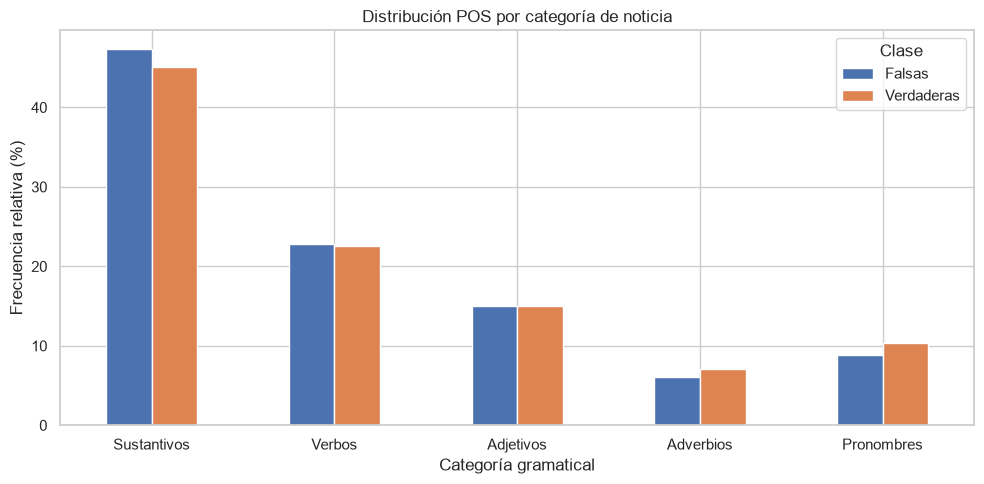

In [92]:
import matplotlib.pyplot as plt

pos_figure = plot_pos_distribution(pos_counts)
display(pos_figure)
RESULTS_POS_DIR = ROOT / "results" / "pos_ner"
RESULTS_POS_DIR.mkdir(parents=True, exist_ok=True)
pos_figure.savefig(RESULTS_POS_DIR / "pos_distribution.png", dpi=160, bbox_inches="tight")
plt.close(pos_figure)
pos_table.to_csv(RESULTS_POS_DIR / "pos_comparative_table.csv", encoding="utf-8")

In [93]:
top_nouns_true = top_words(word_counts, label=1, pos="NOUN", n=10)
top_nouns_false = top_words(word_counts, label=0, pos="NOUN", n=10)
top_verbs_true = top_words(word_counts, label=1, pos="VERB", n=10)
top_verbs_false = top_words(word_counts, label=0, pos="VERB", n=10)
top_adjectives_true = top_words(word_counts, label=1, pos="ADJ", n=10)
top_adjectives_false = top_words(word_counts, label=0, pos="ADJ", n=10)

display(top_nouns_true)
display(top_nouns_false)
display(top_verbs_true)
display(top_verbs_false)
display(top_adjectives_true)
display(top_adjectives_false)

,label,noticia,POS,token,frecuencia
0,1,Verdaderas,NOUN,año,857
1,1,Verdaderas,NOUN,país,562
2,1,Verdaderas,NOUN,presidente,454
3,1,Verdaderas,NOUN,persona,400
4,1,Verdaderas,NOUN,partido,363
5,1,Verdaderas,NOUN,gobierno,354
6,1,Verdaderas,NOUN,parte,351
7,1,Verdaderas,NOUN,día,337
8,1,Verdaderas,NOUN,caso,329
9,1,Verdaderas,NOUN,acuerdo,292


,label,noticia,POS,token,frecuencia
0,0,Falsas,NOUN,partido,502
1,0,Falsas,NOUN,vídeo,448
2,0,Falsas,NOUN,presidente,427
3,0,Falsas,NOUN,vers,399
4,0,Falsas,NOUN,año,388
5,0,Falsas,NOUN,persona,365
6,0,Falsas,NOUN,ley,331
7,0,Falsas,NOUN,caso,316
8,0,Falsas,NOUN,red,299
9,0,Falsas,NOUN,imagen,295


,label,noticia,POS,token,frecuencia
0,1,Verdaderas,VERB,tener,999
1,1,Verdaderas,VERB,hacer,751
2,1,Verdaderas,VERB,decir,693
3,1,Verdaderas,VERB,pedir,386
4,1,Verdaderas,VERB,dar,367
5,1,Verdaderas,VERB,recibir,320
6,1,Verdaderas,VERB,seguir,301
7,1,Verdaderas,VERB,llegar,297
8,1,Verdaderas,VERB,ver,280
9,1,Verdaderas,VERB,asegurar,274


,label,noticia,POS,token,frecuencia
0,0,Falsas,VERB,tener,686
1,0,Falsas,VERB,hacer,496
2,0,Falsas,VERB,asegurar,413
3,0,Falsas,VERB,pedir,334
4,0,Falsas,VERB,decir,329
5,0,Falsas,VERB,afirmar,257
6,0,Falsas,VERB,dar,252
7,0,Falsas,VERB,señalar,207
8,0,Falsas,VERB,explicar,201
9,0,Falsas,VERB,presentar,191


,label,noticia,POS,token,frecuencia
0,1,Verdaderas,ADJ,nuevo,537
1,1,Verdaderas,ADJ,primero,388
2,1,Verdaderas,ADJ,político,289
3,1,Verdaderas,ADJ,último,262
4,1,Verdaderas,ADJ,público,206
5,1,Verdaderas,ADJ,importante,196
6,1,Verdaderas,ADJ,social,182
7,1,Verdaderas,ADJ,mayor,170
8,1,Verdaderas,ADJ,solo,168
9,1,Verdaderas,ADJ,económico,167


,label,noticia,POS,token,frecuencia
0,0,Falsas,ADJ,nuevo,358
1,0,Falsas,ADJ,social,337
2,0,Falsas,ADJ,político,248
3,0,Falsas,ADJ,primero,247
4,0,Falsas,ADJ,español,220
5,0,Falsas,ADJ,público,208
6,0,Falsas,ADJ,último,196
7,0,Falsas,ADJ,general,172
8,0,Falsas,ADJ,viral,133
9,0,Falsas,ADJ,electoral,132


{'pos_counts': WindowsPath('C:/Users/maria/OneDrive/Documentos/2026/PLN/Noticias-Falsas/results/pos_ner/pos_frequencies.csv'),
 'word_counts': WindowsPath('C:/Users/maria/OneDrive/Documentos/2026/PLN/Noticias-Falsas/results/pos_ner/pos_token_frequencies.csv'),
 'table': WindowsPath('C:/Users/maria/OneDrive/Documentos/2026/PLN/Noticias-Falsas/results/pos_ner/pos_comparative_table.csv'),
 'figure': WindowsPath('C:/Users/maria/OneDrive/Documentos/2026/PLN/Noticias-Falsas/results/pos_ner/pos_distribution.png')}

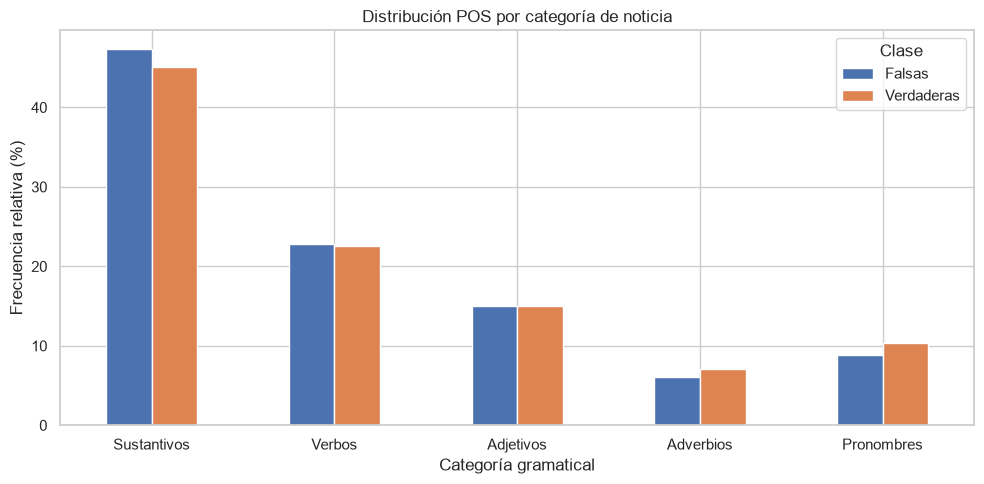

In [94]:
paths_pos = save_pos_results(pos_counts, word_counts, RESULTS_POS_DIR)
paths_pos

### Interpretación inicial

La tabla y el gráfico permiten comparar la proporción de cada categoría respecto del total de tokens de las cinco categorías analizadas en cada clase. Si se dividiera entre todos los tokens del corpus, las proporciones no sumarían 100% porque se omitirían otras etiquetas POS, como determinantes, artículos, adposiciones y conjunciones. Las diferencias deben interpretarse junto con la longitud y el tema de las noticias: una mayor frecuencia relativa no demuestra por sí sola que una categoría gramatical sea un indicador suficiente de falsedad.

## 4. Reconocimiento de Entidades Nombradas (NER)

Se extraen las entidades reconocidas por spaCy sobre el texto crudo. Cada fila representa una menci?n y conserva el documento, la clase, el texto de la entidad y su tipo. Las repeticiones se mantienen porque son necesarias para calcular frecuencias.

In [95]:
from src.pos_ner import (
    extract_entities,
    summarize_entities,
    entity_type_distribution,
    top_global_entities,
    plot_ner_distribution,
    plot_top_entities,
    save_ner_results,
)

ner_entities = extract_entities(metadata, nlp, text_column="text", label_column="label")
ner_summaries = summarize_entities(ner_entities, top_n=10)

print(f"Menciones detectadas: {len(ner_entities):,}")
print(f"Documentos con entidades: {ner_entities['doc_id'].nunique():,}")
display(ner_entities.head())

Menciones detectadas: 50,648
Documentos con entidades: 5,286


,doc_id,label,clase,entidad,tipo
0,ds_falso_0001,0,Falsas,Gobierno andaluz,LOC
1,ds_falso_0001,0,Falsas,Junta,MISC
2,ds_falso_0001,0,Falsas,Consejería de Agricultura,LOC
3,ds_falso_0001,0,Falsas,Carmen Crespo,PER
4,ds_falso_0001,0,Falsas,BNG,ORG


In [96]:
# Total de entidades y distribuci?n porcentual por tipo dentro de cada clase.
ner_by_class = ner_summaries["by_class"]
ner_type_distribution = entity_type_distribution(ner_entities)
display(ner_by_class)
display(ner_type_distribution)

,label,clase,menciones,entidades_unicas,documentos
0,0,Falsas,24207,8025,2646
1,1,Verdaderas,26441,9994,2640


,label,clase,tipo,menciones,documentos,porcentaje
0,0,Falsas,LOC,7643,2084,31.573512
1,0,Falsas,PER,6091,2242,25.162143
2,0,Falsas,MISC,5690,2041,23.505598
3,0,Falsas,ORG,4783,1867,19.758747
4,1,Verdaderas,LOC,8765,2072,33.149276
5,1,Verdaderas,MISC,6651,2015,25.154117
6,1,Verdaderas,PER,6617,1878,25.025529
7,1,Verdaderas,ORG,4408,1733,16.671079


In [97]:
# Diez entidades más frecuentes por tipo para cada clase.
ner_top_by_type = ner_summaries["top_entities"]
display(ner_top_by_type[ner_top_by_type["label"] == 1])
display(ner_top_by_type[ner_top_by_type["label"] == 0])

,label,clase,tipo,entidad,frecuencia
40,1,Verdaderas,LOC,Gobierno,343
41,1,Verdaderas,LOC,EE.UU.,245
42,1,Verdaderas,LOC,Venezuela,245
43,1,Verdaderas,LOC,Colombia,160
44,1,Verdaderas,LOC,Estados Unidos,151
45,1,Verdaderas,LOC,Madrid,149
46,1,Verdaderas,LOC,Estado,136
47,1,Verdaderas,LOC,Reino Unido,96
48,1,Verdaderas,LOC,Cuba,92
49,1,Verdaderas,LOC,Argentina,88


,label,clase,tipo,entidad,frecuencia
0,0,Falsas,LOC,Ceuta,619
1,0,Falsas,LOC,Gobierno,506
2,0,Falsas,LOC,Marruecos,236
3,0,Falsas,LOC,Madrid,216
4,0,Falsas,LOC,Coalición Canaria,205
5,0,Falsas,LOC,España,190
6,0,Falsas,LOC,Nueva Canarias,184
7,0,Falsas,LOC,Qué,126
8,0,Falsas,LOC,Melilla,96
9,0,Falsas,LOC,Comunidad de Madrid,92


In [98]:
# Veinte entidades m?s frecuentes globalmente por categor?a.
ner_top_true = top_global_entities(ner_entities, label=1, n=20)
ner_top_false = top_global_entities(ner_entities, label=0, n=20)
display(ner_top_true)
display(ner_top_false)

,label,clase,entidad,frecuencia
0,1,Verdaderas,PP,590
1,1,Verdaderas,Gobierno,394
2,1,Verdaderas,PSOE,330
3,1,Verdaderas,EE.UU.,245
4,1,Verdaderas,Venezuela,245
5,1,Verdaderas,Vox,231
6,1,Verdaderas,Congreso,181
7,1,Verdaderas,España,178
8,1,Verdaderas,También,174
9,1,Verdaderas,Colombia,160


,label,clase,entidad,frecuencia
0,0,Falsas,Ceuta,619
1,0,Falsas,Gobierno,566
2,0,Falsas,Iniciativa vers per Catalunya,474
3,0,Falsas,España,393
4,0,Falsas,PP,310
5,0,Falsas,BNG,279
6,0,Falsas,Cristina Narbona,245
7,0,Falsas,Congreso,237
8,0,Falsas,EQUO,236
9,0,Falsas,Marruecos,236


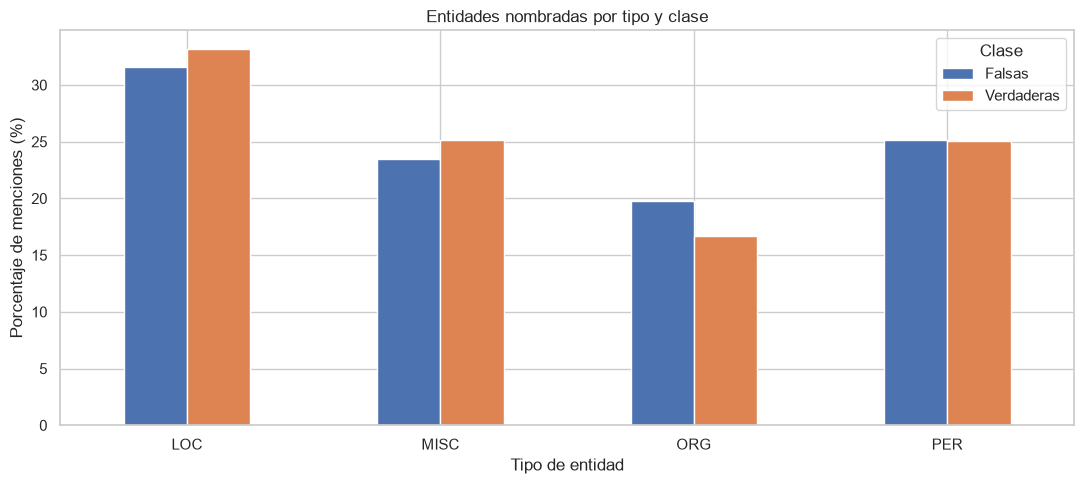

In [99]:
import matplotlib.pyplot as plt

RESULTS_NER_DIR = ROOT / "results" / "ner"
RESULTS_NER_DIR.mkdir(parents=True, exist_ok=True)

ner_distribution_figure = plot_ner_distribution(ner_entities)
display(ner_distribution_figure)
ner_distribution_figure.savefig(RESULTS_NER_DIR / "ner_distribution.png", dpi=160, bbox_inches="tight")
plt.close(ner_distribution_figure)

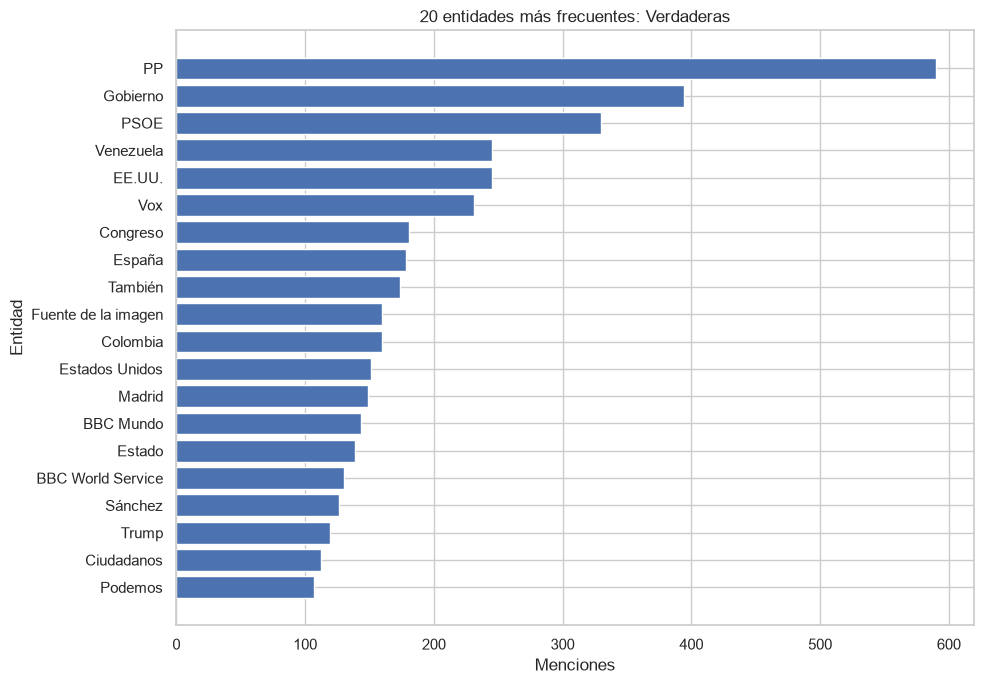

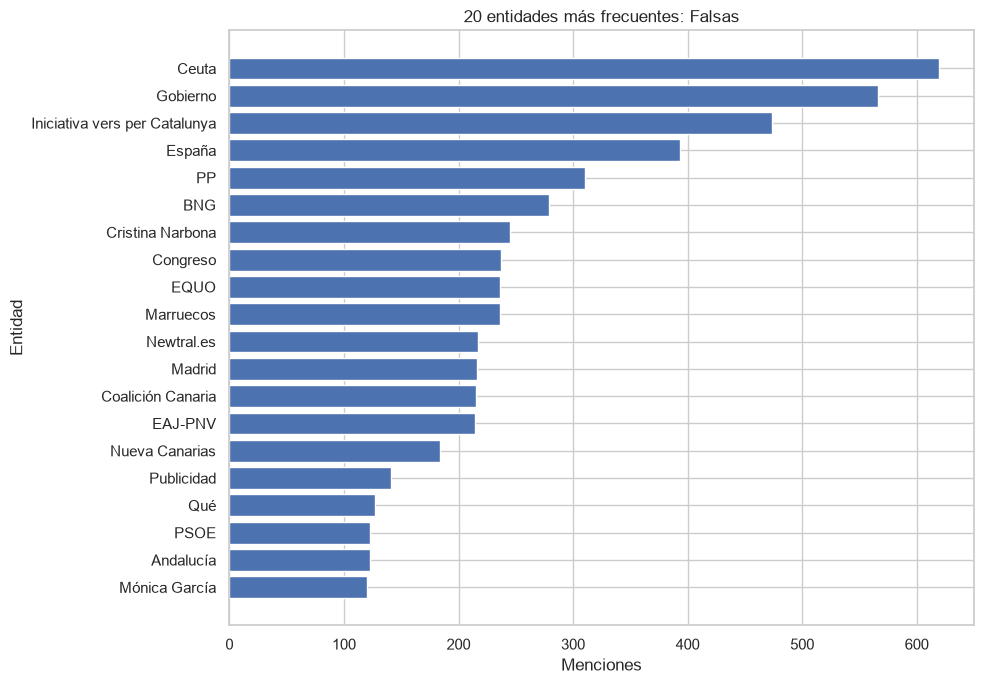

In [100]:
true_figure = plot_top_entities(ner_entities, label=1, n=20)
false_figure = plot_top_entities(ner_entities, label=0, n=20)
display(true_figure)
display(false_figure)
true_figure.savefig(RESULTS_NER_DIR / "ner_top_verdaderas.png", dpi=160, bbox_inches="tight")
false_figure.savefig(RESULTS_NER_DIR / "ner_top_falsas.png", dpi=160, bbox_inches="tight")
plt.close(true_figure)
plt.close(false_figure)

{'entities': WindowsPath('C:/Users/maria/OneDrive/Documentos/2026/PLN/Noticias-Falsas/results/ner/ner_entities.csv'),
 'summary': WindowsPath('C:/Users/maria/OneDrive/Documentos/2026/PLN/Noticias-Falsas/results/ner/ner_summary.csv'),
 'by_type': WindowsPath('C:/Users/maria/OneDrive/Documentos/2026/PLN/Noticias-Falsas/results/ner/ner_by_type.csv'),
 'top_entities': WindowsPath('C:/Users/maria/OneDrive/Documentos/2026/PLN/Noticias-Falsas/results/ner/ner_top_entities.csv'),
 'by_class': WindowsPath('C:/Users/maria/OneDrive/Documentos/2026/PLN/Noticias-Falsas/results/ner/ner_by_class.csv'),
 'type_distribution': WindowsPath('C:/Users/maria/OneDrive/Documentos/2026/PLN/Noticias-Falsas/results/ner/ner_type_distribution.csv'),
 'top_global_true': WindowsPath('C:/Users/maria/OneDrive/Documentos/2026/PLN/Noticias-Falsas/results/ner/ner_top_global_verdaderas.csv'),
 'top_global_false': WindowsPath('C:/Users/maria/OneDrive/Documentos/2026/PLN/Noticias-Falsas/results/ner/ner_top_global_falsas.csv'

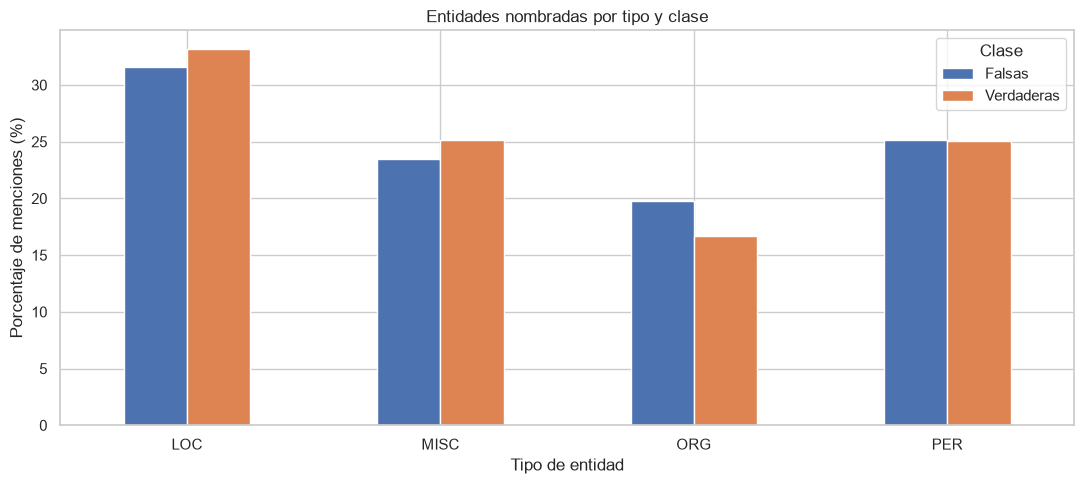

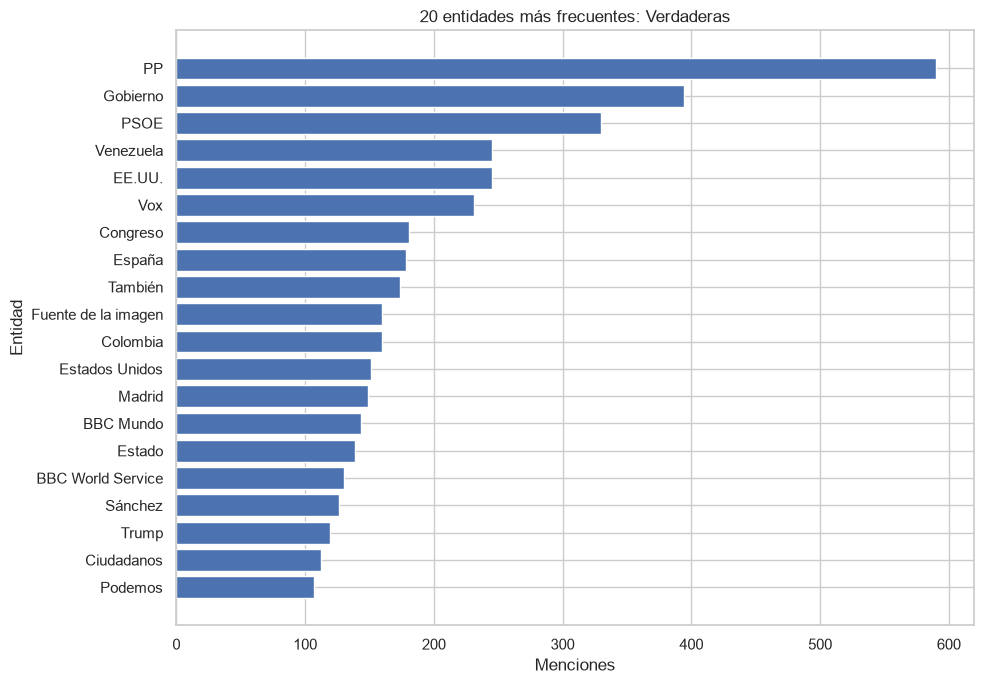

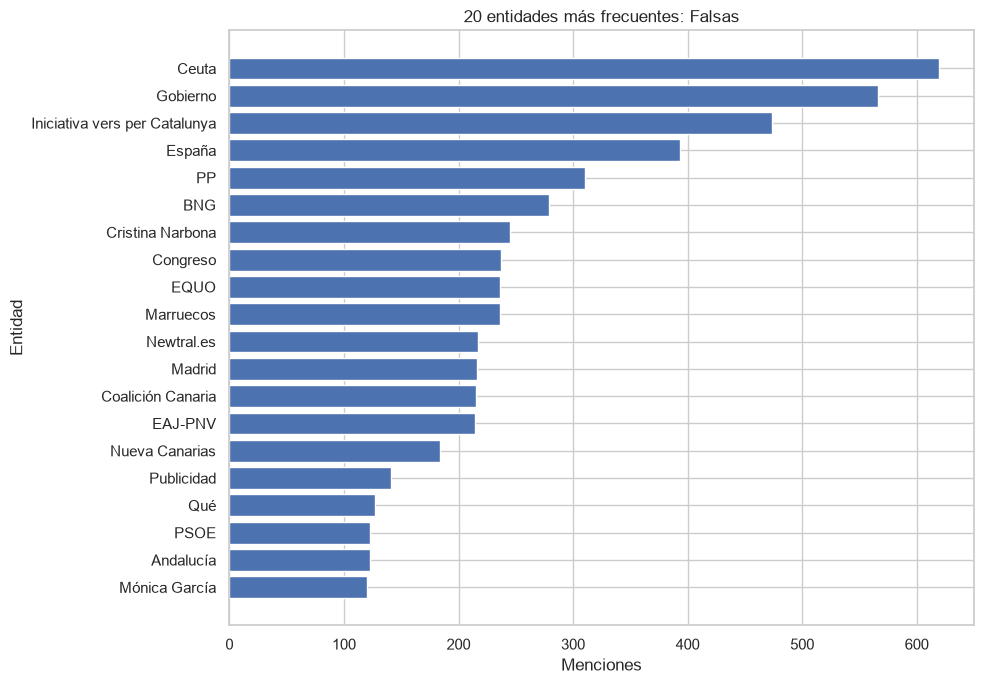

In [101]:
ner_paths = save_ner_results(ner_entities, RESULTS_NER_DIR, top_n=10)
ner_paths

### Revisi?n de errores del modelo

Las predicciones de NER no incluyen una anotaci?n de referencia en el corpus, por lo que los errores deben validarse manualmente. Para el informe se deben seleccionar al menos cinco casos de `ner_entities` y documentar si son falsos positivos, categor?as incorrectas o entidades omitidas. La revisi?n debe incluir el fragmento original, la predicci?n del modelo, la categor?a esperada y la justificaci?n.

In [102]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 5. Extracción de características

En esta sección se usarán unigramas, bigramas, stopwords, stemming, términos de ocurrencia y TF-IDF mediante `src/features.py`.

In [103]:
from src.features import preprocess_for_features, extract_features
from src.topic_modeling import SOURCE_BOILERPLATE

processed = preprocess_for_features(
    processed,
    text_column='clean_text',
    output_column='text_stemmed',
    apply_stopwords=True,
    apply_stemming=True,
    extra_stopwords=SOURCE_BOILERPLATE,
)
processed[['clean_text', 'text_stemmed']].head()

,clean_text,text_stemmed
0,el organo que fiscaliza al gobierno andaluz de...,organ fiscaliz gobiern andaluz defiend legal n...
1,pp pide a cristina narbona igualar los permiso...,pp pid cristin narbon igual permis patern mate...
2,cristina narbona rebaja las hipotesis electora...,cristin narbon rebaj hipotesis electoral abal ...
3,carrero blanco elegida candidata del iniciativ...,carrer blanc eleg candidat inici vers per cata...
4,diego cañamero pide aprobar ya los presupuesto...,dieg cañamer pid aprob presupuest catalan pali...


In [104]:
# 2. Extracción de características con Unigramas y Bigramas (Frecuencia < 3 eliminada)
print("Extrayendo características (BoW)...")

# Utilizando method='bow' para cumplir estrictamente con el requerimiento de Bolsa de Palabras
X_features, vectorizer = extract_features(
    processed, 
    text_column='text_stemmed', 
    method='bow', 
    min_freq=3
)

print(f"Matriz de características creada con éxito.")
print(f"Número de documentos: {X_features.shape[0]}")
print(f"Total de características (unigramas y bigramas válidos): {X_features.shape[1]}")

Extrayendo características (BoW)...
Matriz de características creada con éxito.
Número de documentos: 5300
Total de características (unigramas y bigramas válidos): 19024


In [105]:
feature_names = vectorizer.get_feature_names_out()
freq = np.asarray(X_features.sum(axis=0)).ravel()
top = pd.DataFrame({"término": feature_names, "frecuencia": freq}).sort_values("frecuencia", ascending=False)

print("Unigramas más frecuentes:")
display(top[~top["término"].str.contains(" ")].head(10))
print("Bigramas más frecuentes:")
display(top[top["término"].str.contains(" ")].head(10))

Unigramas más frecuentes:


,término,frecuencia
7994,gobiern,2176
12779,part,1656
14184,president,1393
12097,nuev,1210
14779,public,1096
13955,pp,1045
2651,cas,1013
13734,polit,966
16900,social,958
10485,madr,952


Bigramas más frecuentes:


,término,frecuencia
13163,per cataluny,607
9198,inici vers,605
18515,vers per,605
5818,eaj pnv,302
15387,red social,287
4289,cristin narbon,260
3316,coalicion canari,244
14238,president gobiern,235
12105,nuev canari,215
3608,comun madr,202


## 6. Modelado de temas

Se construyen las matrices con ponderación por frecuencia absoluta (TO) y TF-IDF, usando el mismo vocabulario de unigramas y bigramas

In [106]:
from src.features import extract_features

print("PUNTO 6: Ponderación de Características\n" + "-"*40)

# 1. Frecuencia Absoluta (Term Occurrences - TO)
print("Generando ponderación por Frecuencia Absoluta (TO)...")
X_to, vectorizer_to = extract_features(processed, text_column='text_stemmed', method='bow', min_freq=3)

# 2. Esquema TF-IDF
print("Generando ponderación por TF-IDF...")
X_tfidf, vectorizer_tfidf = extract_features(processed, text_column='text_stemmed', method='tfidf', min_freq=3)

print(f"\nDimensiones de la matriz TO (BoW): {X_to.shape}")
print(f"Dimensiones de la matriz TF-IDF: {X_tfidf.shape}")

PUNTO 6: Ponderación de Características
----------------------------------------
Generando ponderación por Frecuencia Absoluta (TO)...
Generando ponderación por TF-IDF...

Dimensiones de la matriz TO (BoW): (5300, 19024)
Dimensiones de la matriz TF-IDF: (5300, 19024)


## 7. Clasificación

En esta sección se compararán cuatro algoritmos y ocho configuraciones usando validación cruzada mediante `src/classify.py`.

El modelado de temas es no supervisado. Para no fijar el número de temas k de forma arbitraria,
se calcula el Score de Coherencia (c_v) para k = 2..10 (7.3) y se usa el k elegido en LSA (7.1) y LDA (7.2).

In [107]:
from src.topic_modeling import (
    SOURCE_BOILERPLATE, prepare_gensim_corpus, calculate_coherence_values,
    plot_coherence, run_lsa, run_lda,
)

textos_limpios = processed["clean_text"].tolist()
dictionary, corpus, tokenized_texts = prepare_gensim_corpus(
    textos_limpios, extra_stopwords=SOURCE_BOILERPLATE
)
print(f"Vocabulario: {len(dictionary)} términos | Documentos: {len(corpus)}")

Vocabulario: 7584 términos | Documentos: 5300


Calculamos la coherencia para $k$ entre 2 y 10 utilizando LDA.

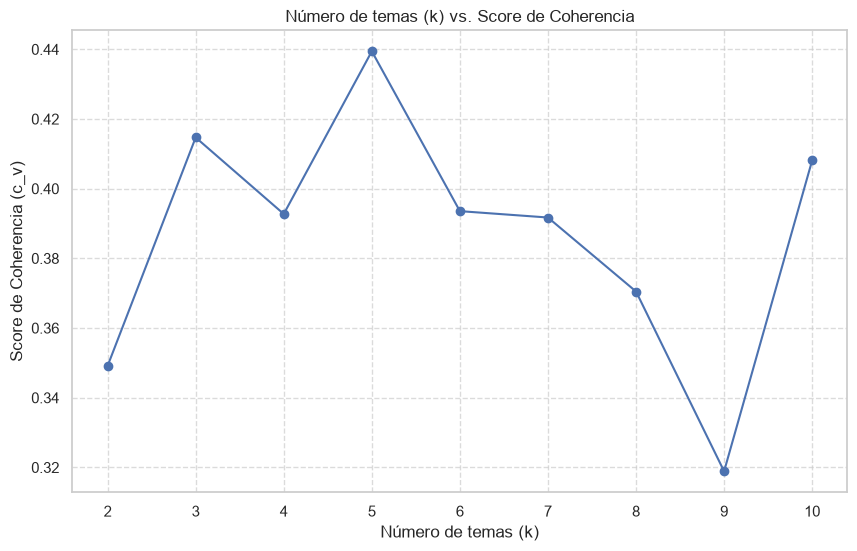

In [108]:
# Calcular valores de coherencia para k de 2 a 10
inicio, limite, paso = 2, 10, 1
coherence_scores = calculate_coherence_values(
    dictionary=dictionary, 
    corpus=corpus, 
    texts=tokenized_texts, 
    start=inicio, 
    limit=limite, 
    step=paso
)

# Generar la gráfica
plot_coherence(inicio, limite, paso, coherence_scores)

In [109]:
ks = list(range(inicio, limite + 1, paso))
tabla_coh = pd.DataFrame({"k": ks, "c_v": np.round(coherence_scores, 4)})
display(tabla_coh)

k_optimo = ks[int(np.argmax(coherence_scores))]
print(f"k con mayor coherencia: {k_optimo}")

,k,c_v
0,2,0.3491
1,3,0.4147
2,4,0.3927
3,5,0.4394
4,6,0.3935
5,7,0.3917
6,8,0.3705
7,9,0.3189
8,10,0.4081


k con mayor coherencia: 5


### 7.1 Latent Semantic Analysis (LSA)

Aplicamos TF-IDF y SVD para extraer los temas.

In [110]:
lsa_model, vectorizer_lsa, lsa_topics = run_lsa(
    textos_limpios, num_topics=k_optimo, top_n=10, extra_stopwords=SOURCE_BOILERPLATE
)

print(f"Top 10 palabras por tema usando LSA (k={k_optimo}):\n")
for tema, palabras in lsa_topics.items():
    print(f"{tema}: {', '.join(palabras)}")

Top 10 palabras por tema usando LSA (k=5):

Tema 1: catalunya, per, iniciativa, vers, gobierno, equo, pp, madrid, partido, presidente
Tema 2: vers, per, iniciativa, catalunya, equo, boluarte, canaria, coalicion, cs, riba
Tema 3: pnv, eaj, pp, equo, unidas, canarias, psoe, congreso, andalucia, coalicion
Tema 4: eaj, pnv, nueva, bng, canarias, ley, maestre, rita, echenique, reforma
Tema 5: madrid, comunidad, partido, pablo, presidenta, elecciones, echenique, ayuso, pp, vox


**Interpretación manual de los temas (LSA, k = 5):**

* **Tema 1 (Política nacional y Cataluña):** *gobierno, partido, presidente, madrid, pp*, junto con
  *catalunya, iniciativa, vers, per, equo*. Es el componente principal: mezcla vocabulario político
  general con la coalición Iniciativa per Catalunya Verds.
* **Tema 2 (Coaliciones de izquierda y verdes):** casi repite el Tema 1 (*vers, per, iniciativa,
  catalunya, equo*), con nombres propios (*boluarte, riba, cs, coalicion, canaria*).
* **Tema 3 (Partidos nacionalistas y coaliciones regionales):** *pnv, eaj, pp, equo, unidas, canarias,
  psoe, congreso, andalucia, coalicion*. Agrupa formaciones de las comunidades autónomas.
* **Tema 4 (Reforma legal y nacionalistas):** *eaj, pnv, nueva, bng, canarias* junto con *ley,
  reforma, maestre, rita, echenique*. Se solapa con el Tema 3.
* **Tema 5 (Madrid y elecciones):** *madrid, comunidad, presidenta, elecciones, ayuso, pp, vox,
  echenique, pablo*. Es el más limpio e interpretable.

LSA muestra redundancia: los temas 1–2 y 3–4 se parecen mucho, y casi todos giran en torno
a siglas y nombres propios de partidos. Esto indica que el método capta la co-ocurrencia de pocas
entidades muy repetidas (como "Iniciativa per Catalunya Verds", frecuente en el corpus de
noticias falsas) más que temas semánticos distintos. Además, los componentes de SVD pueden tener
signos mixtos y no representan probabilidades, lo que dificulta su interpretación como "temas".

### 7.2 Latent Dirichlet Allocation (LDA)

Aplicamos LDA utilizando Bag of Words y Gensim con el mismo número de temas.

In [111]:
lda_model, lda_topics = run_lda(corpus, dictionary, num_topics=k_optimo, top_n=10)

print(f"Top 10 palabras por tema usando LDA (k={k_optimo}):\n")
for tema, palabras in lda_topics.items():
    print(f"{tema}: {', '.join(palabras)}")

Top 10 palabras por tema usando LDA (k=5):

Tema 1: gobierno, pais, segun, españa, presidente, dijo, paises, ser, años, latina
Tema 2: gobierno, pp, sanchez, congreso, podemos, ley, psoe, partido, presidente, madrid
Tema 3: ceuta, video, personas, redes, sociales, marruecos, mensajes, migrantes, embargo, españa
Tema 4: años, colombia, venezuela, eeuu, pais, personas, noticias, caso, nacional, parte
Tema 5: catalunya, iniciativa, per, vers, madrid, gobierno, equo, andalucia, canaria, supremo


**Interpretación manual de los temas (LDA, k = 5):**

* **Tema 1 (Gobiernos y actualidad internacional):** *gobierno, pais, segun, españa, presidente,
  dijo, paises, años, latina*. Declaraciones de presidentes y gobiernos de España y América Latina,
  con tono de reportaje (*según, dijo*).
* **Tema 2 (Gobierno central y Congreso):** *gobierno, pp, sanchez, congreso, podemos, ley, psoe,
  partido, presidente, madrid*. Actividad del Ejecutivo y del Congreso, con los partidos nacionales.
* **Tema 3 (Ceuta, migración y redes sociales):** *ceuta, marruecos, migrantes, video, personas,
  redes, sociales, mensajes*. Combina la crisis fronteriza con contenido viral y su verificación.
* **Tema 4 (Latinoamérica y EE.UU.):** *colombia, venezuela, eeuu, pais, personas, noticias, caso,
  nacional, años*. Noticias sobre otros países, con vocabulario de casos y sucesos.
* **Tema 5 (Coaliciones y partidos regionales):** *catalunya, iniciativa, per, vers, equo, madrid,
  andalucia, canaria, gobierno*. Coalición Iniciativa per Catalunya Verds, Equo y formaciones de
  Andalucía y Canarias. La aparición de *supremo* sugiere que mezcla algo de vocabulario judicial.

**Conclusión del modelado de temas:**

LDA produjo temas más distintos e interpretables que LSA: separó política nacional, coaliciones
regionales, crisis de Ceuta/redes sociales y noticias de Latinoamérica y EE.UU. LSA, en cambio, mostró
redundancia entre componentes (temas 1–2 y 3–4) y un vocabulario dominado por nombres de partidos.
Por eso LDA es el modelo que se usa para el análisis por veracidad (§8).

## 8. ANÁLISIS DE TEMAS SEGÚN LA VERACIDAD DE LAS NOTICIAS 

Se determina el tema dominante para cada documento a partir del modelo de temas seleccionado. Posteriormente, se evalúa la distribución porcentual de los temas entre noticias verdaderas (`label=1`) y falsas (`label=0`).

In [119]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency
from src.topic_analysis import (
    get_dominant_topic, compute_topic_distribution_table, plot_topic_comparison
)

topic_labels = {
    0: "Gobiernos y actualidad internacional",
    1: "Gobierno central y Congreso",
    2: "Ceuta, migración y redes sociales",
    3: "Latinoamérica y EE.UU.",
    4: "Coaliciones y partidos regionales",
}

assert len(topic_labels) == k_optimo, f"Tienes {len(topic_labels)} etiquetas pero k_optimo = {k_optimo}"

doc_topic_matrix = np.zeros((len(corpus), k_optimo))
for i, bow in enumerate(corpus):
    for t, p in lda_model.get_document_topics(bow, minimum_probability=0):
        doc_topic_matrix[i, t] = p

vacios = np.array([len(b) == 0 for b in corpus])
print(f"Documentos sin tema (vacíos tras filtrar): {vacios.sum()}")

processed["dominant_topic"] = get_dominant_topic(doc_topic_matrix, topic_labels=topic_labels).values
processed_ok = processed[~vacios]

Documentos sin tema (vacíos tras filtrar): 0


In [120]:
topic_words = {topic_labels[i]: lda_topics[f"Tema {i+1}"] for i in topic_labels}

interpretations = {
    "Gobiernos y actualidad internacional": "Declaraciones de presidentes y gobiernos de España y América Latina, con tono de reportaje (según, dijo).",
    "Gobierno central y Congreso": "Actividad del Ejecutivo y del Congreso, con partidos nacionales (PP, PSOE, Podemos).",
    "Ceuta, migración y redes sociales": "Crisis fronteriza en Ceuta y contenido viral (videos, mensajes) verificado en redes.",
    "Latinoamérica y EE.UU.": "Noticias sobre Colombia, Venezuela y EE.UU., con vocabulario de casos y sucesos.",
    "Coaliciones y partidos regionales": "Iniciativa per Catalunya Verds, Equo y formaciones de Andalucía y Canarias.",
}

topic_table = compute_topic_distribution_table(
    processed_ok, topic_column="dominant_topic", label_column="label",
    topic_words=topic_words, interpretations=interpretations,
)
display(topic_table)

chi2, p, _, _ = chi2_contingency(topic_table[["Verdaderas (cantidad)", "Falsas (cantidad)"]])
print(f"Chi-cuadrado = {chi2:.1f}, p = {p:.2e}")

,Tema,Palabras representativas,Verdaderas (cantidad),Verdaderas (%),Falsas (cantidad),Falsas (%),Interpretación
0,"Ceuta, migración y redes sociales","ceuta, video, personas, redes, sociales, marru...",83,3.13,134,5.06,Crisis fronteriza en Ceuta y contenido viral (...
1,Coaliciones y partidos regionales,"catalunya, iniciativa, per, vers, madrid, gobi...",434,16.38,778,29.36,"Iniciativa per Catalunya Verds, Equo y formaci..."
2,Gobierno central y Congreso,"gobierno, pp, sanchez, congreso, podemos, ley,...",1534,57.89,1427,53.85,"Actividad del Ejecutivo y del Congreso, con pa..."
3,Gobiernos y actualidad internacional,"gobierno, pais, segun, españa, presidente, dij...",241,9.09,170,6.42,Declaraciones de presidentes y gobiernos de Es...
4,Latinoamérica y EE.UU.,"años, colombia, venezuela, eeuu, pais, persona...",358,13.51,141,5.32,"Noticias sobre Colombia, Venezuela y EE.UU., c..."


Chi-cuadrado = 220.1, p = 1.77e-46


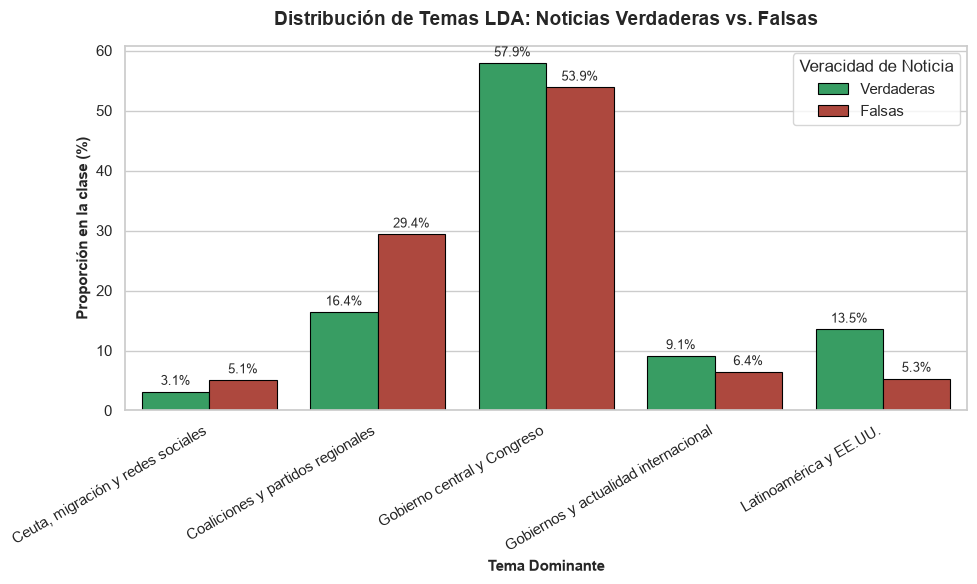

In [121]:
import matplotlib.pyplot as plt

(ROOT / "results").mkdir(exist_ok=True)
fig = plot_topic_comparison(topic_table, title="Distribución de Temas LDA: Noticias Verdaderas vs. Falsas")
display(fig)
fig.savefig(ROOT / "results" / "topics_comparison.png", dpi=160, bbox_inches="tight")
plt.close(fig)

### Análisis de la distribución temática según la veracidad de las noticias

La prueba chi-cuadrado (χ² = 220.1, 4 g.l., p ≈ 1.8 × 10⁻⁴⁶) indica que la distribución de temas
**difiere significativamente** entre noticias verdaderas y falsas. El tamaño del efecto es pequeño a
moderado (V de Cramér ≈ 0.20): hay diferencias reales, pero los temas por sí solos no separan las clases.

**Temas con mayor presencia en noticias falsas**

* **Coaliciones y partidos regionales:** 29.4% de las falsas frente a 16.4% de las verdaderas
  (+13.0 puntos, ≈ 1.8 veces más). Es la mayor diferencia. El vocabulario del tema (*catalunya,
  iniciativa, per, vers, equo*) corresponde a la coalición Iniciativa per Catalunya Verds, que se
  repite de forma masiva en las noticias falsas del dataset de Kaggle; por eso es probable que este
  resultado refleje una característica del corpus y no un patrón general de la desinformación.
* **Ceuta, migración y redes sociales:** 5.1% frente a 3.1% (+1.9 puntos). La diferencia es
  pequeña, pero coherente con que las verificaciones de Newtral, etiquetadas como falsas, tratan
  contenido viral sobre la crisis de Ceuta.

**Temas con mayor presencia en noticias verdaderas**

* **Latinoamérica y EE.UU.:** 13.5% frente a 5.3% (+8.2 puntos, ≈ 2.5 veces más).
* **Gobiernos y actualidad internacional:** 9.1% frente a 6.4% (+2.7 puntos).
* **Gobierno central y Congreso:** 57.9% frente a 53.9% (+4.0 puntos). Es el tema dominante en
  ambas clases, por lo que discrimina poco.

**Respuesta a la pregunta del enunciado.** Sí existen temas con presencia proporcionalmente
distinta: las noticias falsas se concentran más en política regional y coaliciones, y las verdaderas
en temas internacionales y de Latinoamérica. Aun así, más de la mitad de cada clase se agrupa en
un mismo tema de política nacional, de modo que el contenido político no basta para distinguir
una noticia verdadera de una falsa.

**Limitaciones.** Estas diferencias dependen de cómo se construyó el corpus: las noticias
verdaderas incluyen reportajes de BBC Mundo (internacionales) y las falsas verificaciones de
Newtral (Ceuta, redes sociales), además del patrón repetido de Iniciativa per Catalunya Verds en
el dataset de Kaggle. Por tanto, los resultados describen diferencias temáticas **de este corpus**
y no una regla general para detectar noticias falsas.